<a href="https://colab.research.google.com/github/ucaokylong/Some_small_projects/blob/main/Text_to_image_synthesis_using_DCGAN_BERTs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Xây dụng và huấn luyện DCGAN tren bộ dữ liệu flower


## Dataset
Thực thi đoạn code sau để tải về bộ dữ liệu, sau đó giải nén thu được 2 thư mục "flowers" - chứa các file .txt chứa các đoạn văn bản mô tả hình ảnh, trong đó mỗi hình ảnh sẽ lấy một mô tả đầu tiên để huấn luyện mô hình và "images" - chứa các hình ảnh.

In [1]:
# Download dataset
!gdown -q 1JJjMiNieTz7xYs6UeVqd02M3DW4fnEfU


In [3]:
!unzip -q /content/cvpr2016_flowers.zip

In [4]:
# Load captions
import os

def load_captions(captions_folder, image_folder):
    captions = {}
    image_files = os.listdir(image_folder)

    for image_file in image_files:
        image_name = image_file.split(".")[0]
        caption_file = os.path.join(captions_folder, image_name + ".txt")
        with open(caption_file, "r") as f:
            caption = f.readlines()[0].strip()
        if image_name not in captions:
            captions[image_name] = caption

    return captions

In [6]:
captions_folder = "/content/content/cvpr2016_flowers/captions"
image_folder = "/content/content/cvpr2016_flowers/images"

captions = load_captions(captions_folder, image_folder)
captions

{'image_05156': 'this flower has long yellow petals and a group of brown anther on it',
 'image_00355': 'the pink and white petals of this flower sits among broad shiny green leaves.',
 'image_05241': 'this flower has petals that are purple with a white stigma',
 'image_04392': 'the petals on this flower are white with a yellow splotch.',
 'image_06859': 'the flower has red petals with green sepals and pedicels.',
 'image_03396': 'this flower is bowl shaped with a checkered color scheme of purple and white.',
 'image_06343': 'this flower has petals that are yellow and very stingy',
 'image_07460': 'the flower shown has purple petals with spots of dark brown on them',
 'image_05250': 'this flower is blue and white in color, with petals that are spotted on the inside.',
 'image_02024': 'this pale pink flower has a large yellow and green pistil.',
 'image_02266': 'the petals are arranged around a round structure that have tiny pink petals.',
 'image_05273': 'the flower shown has blue peta

## Caption Encoder
Trong phần này, sử dụng mô hình BERTs để biểu diễn mỗi câu mô tả thành một vector có kích thước 768 chiều.

In [7]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model = SentenceTransformer("all-mpnet-base-v2").to(device)

def encode_captions(captions):
    encoded_captions = {}
    for image_name in captions.keys():
        caption = captions[image_name]
        encoded_captions[image_name] = {
            "embed": torch.tensor(bert_model.encode(caption)),
            "text": caption
        }
    return encoded_captions

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
encoded_captions = encode_captions(captions)

## Preprocessing

In [38]:
from PIL import Image
from torch.utils.data import Dataset

import random

class FlowerDataset(Dataset):
    def __init__(self, img_dir, captions, transform=None):
        self.img_dir = img_dir
        self.captions = captions
        self.transform = transform
        self.img_names = list(self.captions.keys())

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name + ".jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        encoded_caption = self.captions[img_name]["embed"]
        caption = self.captions[img_name]["text"]

        # Tạo wrong image (chọn ngẫu nhiên một hình ảnh khác)
        wrong_idx = random.choice([i for i in range(len(self.img_names)) if i != idx])
        wrong_img_name = self.img_names[wrong_idx]
        wrong_img_path = os.path.join(self.img_dir, wrong_img_name + ".jpg")
        wrong_image = Image.open(wrong_img_path).convert("RGB")

        if self.transform:
            wrong_image = self.transform(wrong_image)

        return {
            "image": image,
            "embed_caption": encoded_caption,
            "text": caption,
            "wrong_image": wrong_image  # Thêm wrong_image vào batch
        }


In [46]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

ds = FlowerDataset(
    img_dir="/content/content/cvpr2016_flowers/images",
    captions=encoded_captions,
    transform=transform
)

BATCH_SIZE = 64
dataloader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

## Generator

In [85]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_size, feature_size, num_channels, embedding_size, reduced_dim_size):
        super(Generator, self).__init__()
        self.reduced_dim_size = reduced_dim_size

        # Text Encoder
        self.textEncoder = nn.Sequential(
            nn.Linear(in_features=embedding_size, out_features=reduced_dim_size),
            nn.BatchNorm1d(num_features=reduced_dim_size),
            nn.LeakyReLU(negative_slope=0.2, inplace=True)
        )

        # Upsampling Block
        self.upsamplingBlock = nn.Sequential(
            # 256 + 100 --> 1024
            nn.ConvTranspose2d(noise_size + reduced_dim_size, feature_size * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_size * 8),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),

            # 1024 --> 512
            nn.ConvTranspose2d(feature_size * 8, feature_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size * 4),
            nn.ReLU(True),

            # 512 --> 256
            nn.ConvTranspose2d(feature_size * 4, feature_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size * 2),
            nn.ReLU(True),

            # 256 --> 128
            nn.ConvTranspose2d(feature_size * 2, feature_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size),
            nn.ReLU(True),

            # 128 --> 3 (output channels)
            nn.ConvTranspose2d(feature_size, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, text_embeddings):
        encoded_text = self.textEncoder(text_embeddings)
        concat_input = torch.cat([noise, encoded_text], dim=1).unsqueeze(2).unsqueeze(3)
        output = self.upsamplingBlock(concat_input)
        return output

## Discriminator


In [90]:
import torch.nn as nn
import torch

class Discriminator(nn.Module):
    def __init__(self, num_channels, feature_size, embedding_size, reduced_dim_size):
        super(Discriminator, self).__init__()
        self.reduced_dim_size = reduced_dim_size

        # Image Encoder
        self.imageEncoder = nn.Sequential(
            nn.Conv2d(num_channels, feature_size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_size, feature_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_size * 2),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(feature_size * 2 ,feature_size * 4 ,4 ,2 ,1,bias=False),
            nn.BatchNorm2d(feature_size * 4),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(feature_size * 4 ,feature_size * 8 ,4 ,2 ,1,bias=False),
            nn.BatchNorm2d(feature_size * 8),
            nn.LeakyReLU(0.2,inplace=True)
        )

        # Text Encoder
        self.textEncoder = nn.Sequential(
            nn.Linear(in_features=embedding_size,out_features=reduced_dim_size),
            nn.BatchNorm1d(num_features=reduced_dim_size),
            nn.LeakyReLU(negative_slope=0.2,inplace=True)
        )

        # Final Block
        self.finalBlock = nn.Sequential(
            # Giảm xuống [h=1,w=1]
            nn.Conv2d(feature_size *8 + reduced_dim_size ,1,kernel_size=4,stride=1,padding=0,bias=False),
            nn.AdaptiveAvgPool2d((1, 1)), # Đảm bảo đầu ra là [h=1,w=1]
            nn.Flatten(), # Chuyển từ [batch x channels x h x w] thành [batch x channels]
            nn.Sigmoid()
        )

    def forward(self,input_img,text_embeddings):
        image_encoded=self.imageEncoder(input_img)
        text_encoded=self.textEncoder(text_embeddings)

        replicated_text=text_encoded.unsqueeze(2).unsqueeze(3)
        replicated_text=replicated_text.repeat_interleave(image_encoded.shape[2],dim=2)
        replicated_text=replicated_text.repeat_interleave(image_encoded.shape[3],dim=3)

        concat_layer=torch.cat([image_encoded ,replicated_text],dim=1)

        x=self.finalBlock(concat_layer)

        return x,image_encoded




#Training

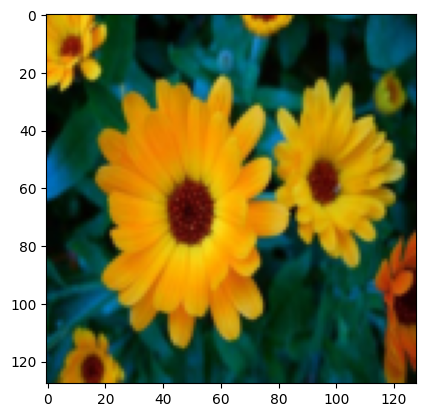

In [87]:
import matplotlib.pyplot as plt
import torchvision

def show_grid(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

show_grid(torchvision.utils.make_grid(ds[0]["image"], normalize=True))

def plot_output(generator):
    plt.clf()
    with torch.no_grad():
        generator.eval()
        test_images = generator(fixed_noise.to(device), plt_o_text_embeddings.to(device))
        generator.train()

        grid = torchvision.utils.make_grid(test_images.cpu(), normalize=True)
        show_grid(grid)


In [91]:
import torch.optim as optim

# Khởi tạo Generator và Discriminator
generator = Generator(100, 128, 3, 768, 256).to(device)
discriminator = Discriminator(3, 128, 768, 256).to(device)

# Optimizers cho Generator và Discriminator
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss functions
bce_loss = nn.BCELoss()
l2_loss = nn.MSELoss()
l1_loss = nn.L1Loss()


Epoch [1/50] Loss D: 0.6383 Loss G: 4.3747 Time: 141.49
Epoch [2/50] Loss D: 0.6280 Loss G: 4.4118 Time: 141.55
Epoch [3/50] Loss D: 0.6284 Loss G: 4.4362 Time: 141.29
Epoch [4/50] Loss D: 0.6229 Loss G: 4.3849 Time: 140.72
Epoch [5/50] Loss D: 0.6241 Loss G: 4.3699 Time: 140.83
Epoch [6/50] Loss D: 0.6255 Loss G: 4.3653 Time: 141.31
Epoch [7/50] Loss D: 0.6312 Loss G: 4.4093 Time: 140.76
Epoch [8/50] Loss D: 0.6291 Loss G: 4.4869 Time: 141.09
Epoch [9/50] Loss D: 0.6209 Loss G: 4.5227 Time: 140.91


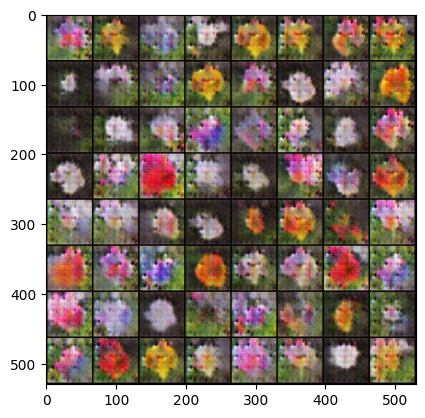

Epoch [10/50] Loss D: 0.6107 Loss G: 4.5441 Time: 140.95
Epoch [11/50] Loss D: 0.6048 Loss G: 4.5596 Time: 141.82
Epoch [12/50] Loss D: 0.6009 Loss G: 4.5724 Time: 141.44
Epoch [13/50] Loss D: 0.5992 Loss G: 4.5828 Time: 141.63
Epoch [14/50] Loss D: 0.6013 Loss G: 4.5880 Time: 141.04
Epoch [15/50] Loss D: 0.5981 Loss G: 4.6146 Time: 140.68
Epoch [16/50] Loss D: 0.5998 Loss G: 4.6212 Time: 141.37
Epoch [17/50] Loss D: 0.5981 Loss G: 4.6323 Time: 140.83
Epoch [18/50] Loss D: 0.5972 Loss G: 4.6521 Time: 141.55
Epoch [19/50] Loss D: 0.5998 Loss G: 4.6835 Time: 141.43


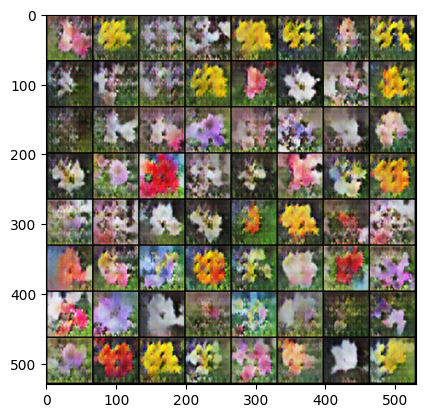

Epoch [20/50] Loss D: 0.5977 Loss G: 4.6901 Time: 140.79
Epoch [21/50] Loss D: 0.5974 Loss G: 4.7185 Time: 141.52
Epoch [22/50] Loss D: 0.5996 Loss G: 4.7550 Time: 140.08
Epoch [23/50] Loss D: 0.5979 Loss G: 4.7925 Time: 141.29
Epoch [24/50] Loss D: 0.5956 Loss G: 4.8398 Time: 140.46
Epoch [25/50] Loss D: 0.5959 Loss G: 4.8691 Time: 140.18
Epoch [26/50] Loss D: 0.5899 Loss G: 4.8787 Time: 140.46
Epoch [27/50] Loss D: 0.5871 Loss G: 4.9155 Time: 140.32
Epoch [28/50] Loss D: 0.5857 Loss G: 4.9347 Time: 140.26
Epoch [29/50] Loss D: 0.5818 Loss G: 4.9635 Time: 140.55


In [ ]:
import time
import os
from torchvision.transforms import Resize

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

epochs = 50
d_losses, g_losses = [], []
accumulation_steps = 8  # Accumulate gradients over 4 steps

# Noise cố định để vẽ đầu ra
fixed_noise = torch.randn(size=(BATCH_SIZE, 100), device=device)
plt_o_text_embeddings = next(iter(dataloader))['embed_caption']

# Resize transform để đảm bảo kích thước khớp giữa fake_images và images
resize_transform = Resize((64, 64))  # Đảm bảo kích thước là [batch_size, channels, 64, 64]

# Training loop
for epoch in range(epochs):
    epoch_time = time.time()
    for i, batch in enumerate(dataloader):
        images = batch["image"].to(device)
        embed_captions = batch["embed_caption"].to(device)
        wrong_images = batch["wrong_image"].to(device)

        # Resize images để khớp với fake_images
        images_resized = resize_transform(images)

        # Labels
        real_labels = torch.ones(images.size(0), 1, device=device)
        fake_labels = torch.zeros(images.size(0), 1, device=device)

        # Training the discriminator
        optimizer_D.zero_grad()

        # Generate fake images
        noise = torch.randn(size=(images.size(0), 100), device=device)
        fake_images = generator(noise, embed_captions)

        # Compute real loss
        outputs, _ = discriminator(images_resized, embed_captions)
        real_loss = bce_loss(outputs, real_labels)

        # Compute contrastive loss for wrong images
        outputs, _ = discriminator(wrong_images, embed_captions)
        wrong_loss = bce_loss(outputs, fake_labels)

        # Compute fake loss
        outputs, _ = discriminator(fake_images.detach(), embed_captions)
        fake_loss = bce_loss(outputs, fake_labels)

        # Total discriminator loss
        d_loss = real_loss + fake_loss + wrong_loss
        d_loss.backward()
        optimizer_D.step()
        d_losses.append(d_loss.item())

        # Training the generator
        optimizer_G.zero_grad()

        # Create noise and generate fake images
        noise = torch.randn(size=(images.size(0), 100), device=device)
        fake_images = generator(noise, embed_captions)

        outputs, fake_features = discriminator(fake_images, embed_captions)
        _, real_features = discriminator(images_resized, embed_captions)

        # Sử dụng AdaptiveAvgPool2d để đảm bảo kích thước giống nhau
        pool = nn.AdaptiveAvgPool2d((4, 4))  # Đảm bảo kích thước là [batch_size, channels, 4, 4]

        fake_features_pooled = pool(fake_features)
        real_features_pooled = pool(real_features)

        activation_fake = torch.mean(fake_features_pooled, dim=(2, 3))  # Trung bình trên chiều không gian
        activation_real = torch.mean(real_features_pooled, dim=(2, 3))  # Trung bình trên chiều không gian

        # Compute generator loss
        real_loss = bce_loss(outputs, real_labels)

        g_loss = real_loss + 100 * l2_loss(activation_fake, activation_real.detach()) + \
                 50 * l1_loss(fake_images, images_resized)  # Sử dụng hình ảnh đã resize

        g_loss.backward()
        optimizer_G.step()
        g_losses.append(real_loss.item())

    avg_d_loss = sum(d_losses) / len(d_losses)
    avg_g_loss = sum(g_losses) / len(g_losses)

    if (epoch + 1) % 10 == 0:
        plot_output(generator)

    print(
        f"Epoch [{epoch + 1}/{epochs}] Loss D: {avg_d_loss:.4f} Loss G: {avg_g_loss:.4f} Time: {time.time() - epoch_time:.2f}"
    )

# Save model
model_save_path = "./save_model"
torch.save(generator.state_dict(), os.path.join(model_save_path, "generator.pth"))
torch.save(discriminator.state_dict(), os.path.join(model_save_path, "discriminator.pth"))


## Deployment

In [ ]:
generator.eval()

caption = "this pale pink flower has a large yellow and green pistil."
embed_caption = torch.tensor(bert_model.encode(caption))
noise = torch.randn(size=(1, 100))
text_embedding = embed_caption.unsqueeze(0)

with torch.no_grad():
    test_images = generator(noise.to(device), text_embedding.to(device))
    grid = torchvision.utils.make_grid(test_images.cpu(), normalize=True)
    show_grid(grid)
